# Air Brakes — Continuous


In [1]:
!python -m pip install -e ../../.

/bin/bash: line 1: python: command not found


## Setting Up The Simulation

First, lets define everything we need for the simulation up to the rocket:

In [2]:
from rocketpy import Environment, SolidMotor, Rocket, Flight

env = Environment(latitude=32.990254, longitude=-106.974998, elevation=1400)

Pro75M1670 = SolidMotor(
    thrust_source="../../data/motors/cesaroni/Cesaroni_M1670.eng",
    dry_mass=1.815,
    dry_inertia=(0.125, 0.125, 0.002),
    nozzle_radius=33 / 1000,
    grain_number=5,
    grain_density=1815,
    grain_outer_radius=33 / 1000,
    grain_initial_inner_radius=15 / 1000,
    grain_initial_height=120 / 1000,
    grain_separation=5 / 1000,
    grains_center_of_mass_position=0.397,
    center_of_dry_mass_position=0.317,
    nozzle_position=0,
    burn_time=3.9,
    throat_radius=11 / 1000,
    coordinate_system_orientation="nozzle_to_combustion_chamber",
)

calisto = Rocket(
    radius=127 / 2000,
    mass=14.426,
    inertia=(6.321, 6.321, 0.034),
    power_off_drag="../../data/rockets/calisto/powerOffDragCurve.csv",
    power_on_drag="../../data/rockets/calisto/powerOnDragCurve.csv",
    center_of_mass_without_motor=0,
    coordinate_system_orientation="tail_to_nose",
)

rail_buttons = calisto.set_rail_buttons(
    upper_button_position=0.0818,
    lower_button_position=-0.618,
    angular_position=45,
)

calisto.add_motor(Pro75M1670, position=-1.255)

nose_cone = calisto.add_nose(
    length=0.55829, kind="vonKarman", position=1.278
)

fin_set = calisto.add_trapezoidal_fins(
    n=4,
    root_chord=0.120,
    tip_chord=0.060,
    span=0.110,
    position=-1.04956,
    cant_angle=0.5,
    airfoil=("../../data/airfoils/NACA0012-radians.txt","radians"),
)

tail = calisto.add_tail(
    top_radius=0.0635, bottom_radius=0.0435, length=0.060, position=-1.194656
)

## Setting Up the Air Brakes

Now we can get started!

To create an air brakes model, we essentially need to define the following:

- The air brakes' **drag coefficient** as a function of the air brakes' **deployment level** and of the **Mach number**. This can be done through a `CSV` file which must have three columns: the first column is the air brakes' **deployment level**, the second column is the **Mach number**, and the third column is the **drag coefficient** added to rocket due to the air brakes at that specific deployment level and Mach number.

- The **controller function**, which takes in as argument information about the simulation up to the current time step, and the `AirBrakes` instance being defined, and sets the desired air brakes' deployment level. The air brakes' deployment level must be between 0 and 1, and is set using the `deployment_level` attribute. Inside this function, any controller logic, filters, and apogee prediction can be implemented.

- The **sampling rate** of the controller function, in seconds. This is the time between each call of the controller function, in simulation time. Must be given in Hertz.

### Defining the Controller Function

Lets start by defining a very simple controller function.

The `controller_function` must take in the following arguments, in this order:

1. `time` (float): The current simulation time in seconds.
2. `sampling_rate` (float): The rate at which the controller function is called, measured in Hertz (Hz).
3. `state` (list): The state vector of the simulation. The state is a list containing the following values, in this order:
   - `x`: The x position of the rocket, in meters.
   - `y`: The y position of the rocket, in meters.
   - `z`: The z position of the rocket, in meters.
   - `v_x`: The x component of the velocity of the rocket, in meters per second.
   - `v_y`: The y component of the velocity of the rocket, in meters per second.
   - `v_z`: The z component of the velocity of the rocket, in meters per second.
   - `e0`: The first component of the quaternion representing the rotation of the rocket.
   - `e1`: The second component of the quaternion representing the rotation of the rocket.
   - `e2`: The third component of the quaternion representing the rotation of the rocket.
   - `e3`: The fourth component of the quaternion representing the rotation of the rocket.
   - `w_x`: The x component of the angular velocity of the rocket, in radians per second.
   - `w_y`: The y component of the angular velocity of the rocket, in radians per second.
   - `w_z`: The z component of the angular velocity of the rocket, in radians per second.

4. `state_history` (list): A record of the rocket's state at each step throughout the simulation. The state_history is organized as a list of lists, with each sublist containing a state vector. The last item in the list always corresponds to the previous state vector.

5. `observed_variables` (list): A list containing the variables that the controller function returns. The return of each controller function call is appended to the observed_variables list. The initial value is provided by the `initial_observed_variables` argument.

6. `air_brakes` (AirBrakes): The `AirBrakes` instance being controlled.

Our example `controller_function` will deploy the air brakes when the rocket reaches 1500 meters above the ground. The deployment level will be a function of the vertical velocity at the current time step and the vertical velocity at the previous time step.

Also, the controller function will check for burnout of the rocket's motor and only deploy the air brakes if burnout has been reached.

A limitation for the opening/closing speed of the air brakes will be set. The air brakes deployment level will not be able to change faster than 20% per second.

In [3]:
import math

def controller_function(
    time, sampling_rate, state, state_history, observed_variables, air_brakes
):
    # state = [x, y, z, vx, vy, vz, e0, e1, e2, e3, wx, wy, wz]
    altitude_ASL = state[2]
    altitude_AGL = altitude_ASL - env.elevation
    vx, vy, vz = state[3], state[4], state[5]

    # Winds at current altitude
    wind_x = env.wind_velocity_x(altitude_ASL)
    wind_y = env.wind_velocity_y(altitude_ASL)

    # Free-stream Mach
    free_stream_speed = (
        (wind_x - vx) ** 2 + (wind_y - vy) ** 2 + (vz) ** 2
    ) ** 0.5
    mach_number = free_stream_speed / env.speed_of_sound(altitude_ASL)

    # Previous record from state_history. Each row is
    # [t, x, y, z, vx, vy, vz, e0, e1, e2, e3, wx, wy, wz]
    previous_state = state_history[-1]
    previous_vz = previous_state[5]

    # Hold air brakes closed until burnout
    if time < Pro75M1670.burn_out_time:
        return None

    # Below 1500 m AGL: keep retracted
    if altitude_AGL < 1500:
        air_brakes.deployment_level = 0
    else:
        new_deployment_level = (
            air_brakes.deployment_level + 0.1 * vz + 0.01 * previous_vz**2
        )

        # Rate limit deployment at 0.2 units/second.
        #
        # In DISCRETE  mode the call cadence is fixed (1/sampling_rate s),
        # so max change per call = 0.2 / sampling_rate.
        #
        # In CONTINUOUS mode the controller is fired once per integrator
        # step, so sampling_rate == math.inf and the per-call window is the
        # actual solver step Δt taken from state_history.
        if math.isinf(sampling_rate):
            dt = time - previous_state[0]
            max_change = 0.2 * dt
        else:
            max_change = 0.2 / sampling_rate

        lower_bound = air_brakes.deployment_level - max_change
        upper_bound = air_brakes.deployment_level + max_change
        new_deployment_level = min(
            max(new_deployment_level, lower_bound), upper_bound
        )
        air_brakes.deployment_level = new_deployment_level

    return (
        time,
        air_brakes.deployment_level,
        air_brakes.drag_coefficient(air_brakes.deployment_level, mach_number),
    )


**Note:**
- The code inside the `controller_function` can be as complex as needed. Anything can be implemented, including filters and apogee prediction.
- The `air_brakes` instance `deployment_level` is clamped between 0 and 1.
- Anything can be returned by the `controller_function`. The returned values will be saved in the `observed_variables` list.
- The `controller_function` can be defined in a separate file and imported.

### Defining the Drag Coefficient

Now lets define the drag coefficient as a function of the air brakes' deployment level and Mach number. We will import the data from a CSV file.

The CSV file must have three columns: deployment level, Mach number, and drag coefficient.

Alternatively, the drag coefficient can be defined as a function that takes deployment level and Mach number as arguments.

**Note:** At deployment level 0, the drag coefficient is always set to 0, regardless of the input curve.

Part of the data from the CSV:

```
deployment_level, mach, cd
0.0, 0.0, 0.0
0.1, 0.0, 0.0
0.1, 0.2, 0.0
0.1, 0.3, 0.01
0.1, 0.4, 0.005
0.1, 0.5, 0.006
0.1, 0.6, 0.018
0.1, 0.7, 0.012
0.1, 0.8, 0.014
0.5, 0.1, 0.051
0.5, 0.2, 0.051
0.5, 0.3, 0.065
0.5, 0.4, 0.061
0.5, 0.5, 0.067
0.5, 0.6, 0.083
0.5, 0.7, 0.08
0.5, 0.8, 0.085
1.0, 0.1, 0.32
1.0, 0.2, 0.225
1.0, 0.3, 0.225
1.0, 0.4, 0.21
1.0, 0.5, 0.19
1.0, 0.6, 0.22
1.0, 0.7, 0.21
1.0, 0.8, 0.218
```

**Note:** The air brakes' drag coefficient curve can represent either:
- The air brakes alone (added to the rocket's drag), or
- Both the air brakes and the rocket together (overrides the rocket's drag)

This is determined by the `override_rocket_drag` argument.

### Adding the Air Brakes to the Rocket

Now we can add the air brakes to the rocket. We will set the `reference_area` to `None` (uses rocket's reference area) and `clamp` to `True` (clamps deployment level between 0 and 1).

In [4]:
# air_brakes = calisto.add_air_brakes(
#     drag_coefficient_curve="../../data/rockets/calisto/air_brakes_cd.csv",
#     controller_function=controller_function,
#     sampling_rate=10,
#     reference_area=None,
#     clamp=True,
#     initial_observed_variables=[0, 0, 0],
#     override_rocket_drag=False,
#     name="Air Brakes",
# )

# air_brakes.all_info()

**Note:** The `initial_observed_variables` argument is optional and provides the initial value for the `observed_variables` list passed to the controller function at the first time step.

### Continuous vs. Discrete Controllers

A **discrete** controller is scheduled on a fixed time grid: it forces the integrator to stop at every `1/sampling_rate` seconds, the controller runs, then integration resumes. Choosing `sampling_rate=10` Hz means exactly 10 evenly-spaced controller calls per simulated second.

A **continuous** controller is *not* a discrete controller running at a very high rate. It is registered with `sampling_rate = math.inf` — which is also the default for `rocketpy.control._Controller` — so the simulator skips the time-node scheduling entirely and instead fires the controller once **per integrator step**. The cadence is whatever Δt the adaptive ODE solver chooses for that region of the trajectory.

**This notebook demonstrates: Continuous.**


### Setting up a **Continuous** controller


Controller sampling_rate = inf  (math.inf => continuous, module default)


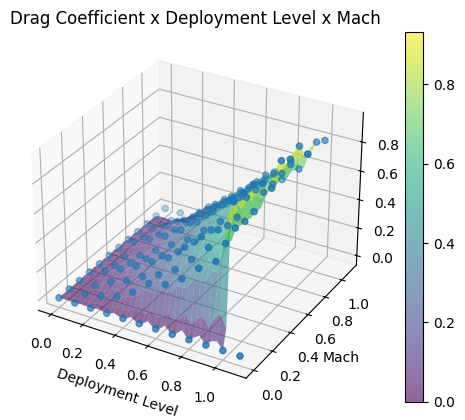

In [5]:
import math
from rocketpy import _Controller
from rocketpy.rocket.aero_surface import AirBrakes

# CONTINUOUS control: _Controller's default sampling_rate is math.inf,
# so omitting the argument selects continuous mode. The controller fires
# once per ODE integrator step at the solver's adaptive Δt.
air_brakes = AirBrakes(
    drag_coefficient_curve="../../data/rockets/calisto/air_brakes_cd.csv",
    reference_area=calisto.area,
    clamp=True,
    override_rocket_drag=False,
    deployment_level=0,
    name="Air Brakes (Continuous)",
)

continuous_controller = _Controller(
    interactive_objects=air_brakes,
    controller_function=controller_function,
    initial_observed_variables=[0, 0, 0],
    name="Continuous Air Brakes Controller",
    # sampling_rate omitted -> defaults to math.inf -> continuous mode
)
calisto._add_controllers(continuous_controller)
calisto.air_brakes.append(air_brakes)

assert math.isinf(continuous_controller.sampling_rate)
print(f"Controller sampling_rate = {continuous_controller.sampling_rate}  (math.inf => continuous, module default)")
air_brakes.all_info()


## Simulating a Flight

**Important:** To simulate the air brakes successfully, we must set `time_overshoot` to `False`. This way the simulation will run at the time step defined by our controller sampling rate. Be aware that this will make the simulation run **much** slower.

We will terminate the simulation at apogee by setting `terminate_on_apogee` to `True`.

In [6]:
test_flight = Flight(
    rocket=calisto,
    environment=env,
    rail_length=5.2,
    inclination=85,
    heading=0,
    time_overshoot=False,
    terminate_on_apogee=True,
)

## Analyzing the Results

Now we can create some plots to analyze the results. We rely on the `observed_variables` list to get the data we want to plot. We can retrieve the `observed_variables` list by calling the `get_controller_observed_variables` method of the `Flight` instance.

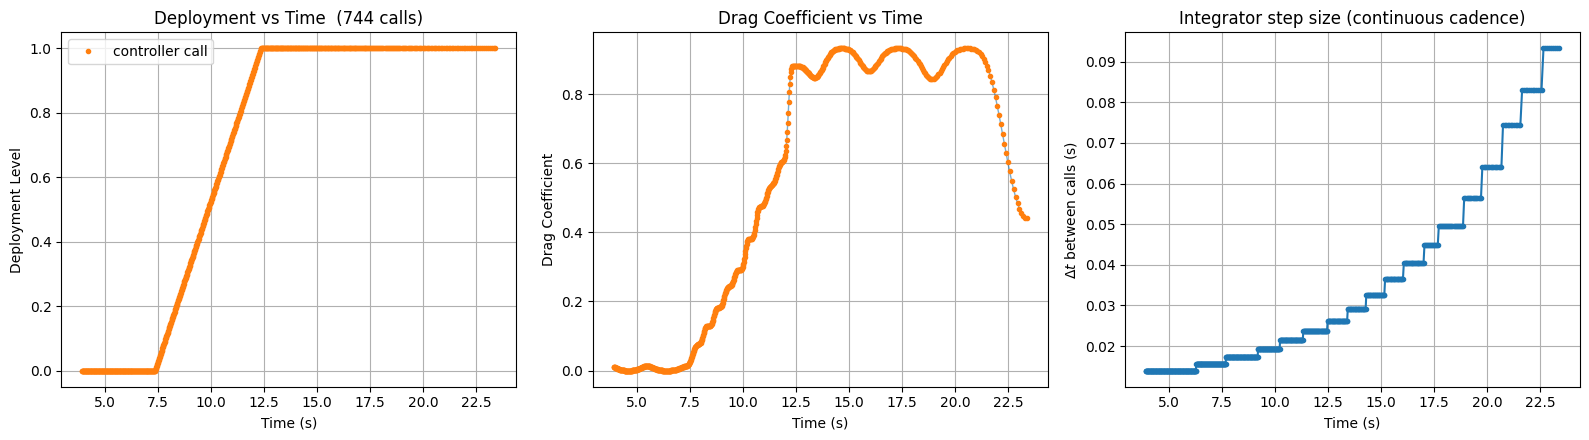

Total controller calls : 744
Mean Δt between calls  : 0.02625 s
Min / Max Δt           : 0.01397 s  /  0.09324 s


In [7]:
import matplotlib.pyplot as plt
import numpy as np

obs_vars = test_flight.get_controller_observed_variables()

# Drop the initial_observed_variables seed ([0, 0, 0]) if present
obs_vars = [row for row in obs_vars if not (row[0] == 0 and row[1] == 0 and row[2] == 0)]

time_list = [row[0] for row in obs_vars]
deployment_level_list = [row[1] for row in obs_vars]
drag_coefficient_list = [row[2] for row in obs_vars]

# Δt between successive controller calls = adaptive integrator step
dts = np.diff(time_list)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (1) Deployment level vs time, with one marker per controller call.
# Each marker is one "node" of the continuous controller — the points
# coincide with the adaptive solver's natural step times.
axes[0].plot(time_list, deployment_level_list, "-", lw=1, alpha=0.6)
axes[0].plot(time_list, deployment_level_list, "o", ms=3, label="controller call")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Deployment Level")
axes[0].set_title(f"Deployment vs Time  ({len(time_list)} calls)")
axes[0].grid(True)
axes[0].legend()

# (2) Drag coefficient over time
axes[1].plot(time_list, drag_coefficient_list, "-", lw=1, alpha=0.6)
axes[1].plot(time_list, drag_coefficient_list, "o", ms=3)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Drag Coefficient")
axes[1].set_title("Drag Coefficient vs Time")
axes[1].grid(True)

# (3) Per-call step size Δt — this is the actual integrator cadence the
# continuous controller is exposed to. Discrete control would show a flat
# horizontal line at 1/sampling_rate.
axes[2].plot(time_list[1:], dts, "o-", ms=3)
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel(r"$\Delta t$ between calls (s)")
axes[2].set_title("Integrator step size (continuous cadence)")
axes[2].grid(True)

plt.tight_layout()
plt.show()

print(f"Total controller calls : {len(time_list)}")
print(f"Mean Δt between calls  : {dts.mean():.4g} s")
print(f"Min / Max Δt           : {dts.min():.4g} s  /  {dts.max():.4g} s")


Finally, let's check some of the simulation results:


Burn out State

Burn out time: 3.900 s
Altitude at burn out: 2057.369 m (ASL) | 657.369 m (AGL)
Rocket speed at burn out: 279.650 m/s
Freestream velocity at burn out: 279.650 m/s
Mach Number at burn out: 0.843
Kinetic energy at burn out: 6.351e+05 J

Apogee State

Apogee Time: 23.369 s
Apogee Altitude: 4401.779 m (ASL) | 3001.779 m (AGL)
Apogee Freestream Speed: 16.157 m/s
Apogee X position: -4.104 m
Apogee Y position: 488.409 m
Apogee latitude: 32.9946458°
Apogee longitude: -106.9750420°


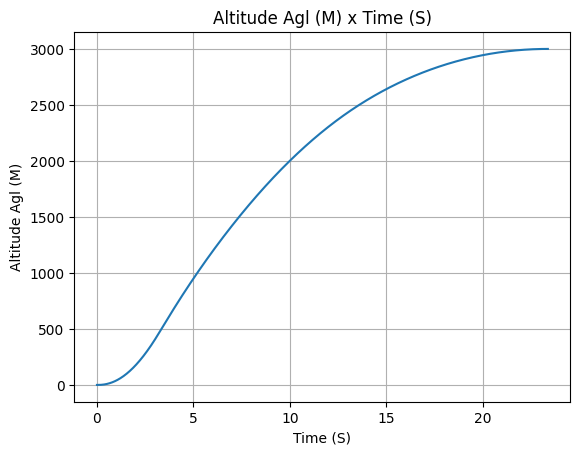

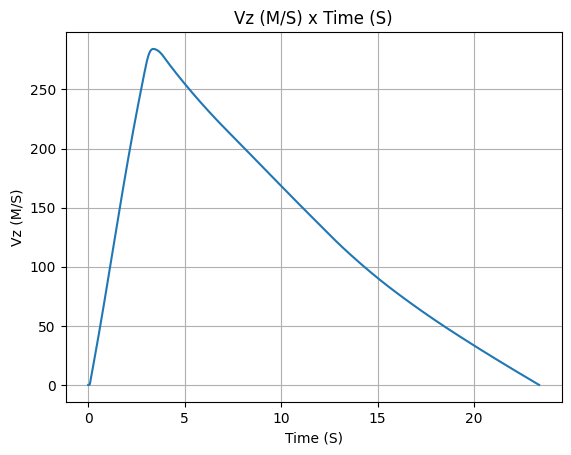


Maximum altitude: 3001.78 m
Vertical velocity at apogee: -0.0002 m/s


In [8]:
test_flight.prints.burn_out_conditions()
test_flight.prints.apogee_conditions()
test_flight.altitude()
test_flight.vz()
print(f"\nMaximum altitude: {test_flight.altitude(test_flight.apogee_time):.2f} m")
print(f"Vertical velocity at apogee: {test_flight.vz(test_flight.apogee_time):.4f} m/s")